Decision Tree and Random Forest Algorithms are trained over Australia weather dataset. It is also applied an approach that finds the best hyperparameters for the model.

## 0. Downloading the Dataset

In [ ]:
!pip install opendatasets --upgrade --quiet

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset_url = "https://www.kaggle.com/jsphyg/weather-dataset-rattle-package"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: krasivachev
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package


100%|██████████| 3.83M/3.83M [00:00<00:00, 439MB/s]

In [ ]:
raw_df = pd.read_csv("/content/weather-dataset-rattle-package/weatherAUS.csv")
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
raw_df.dropna(subset = ["RainToday", "RainTomorrow"], inplace = True)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

## 1. Analyze the Dataset

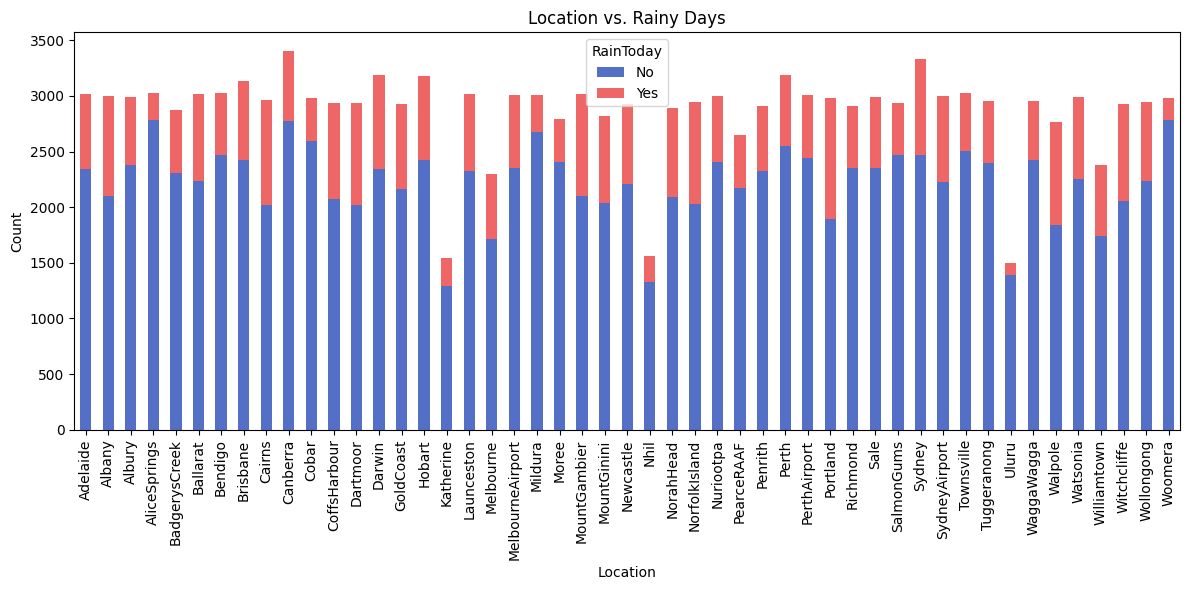

In [ ]:
df_location = raw_df.pivot_table(index = "Location",
                                 columns = "RainToday",
                                 aggfunc = "size")

df_location.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], figsize=(12, 6))

plt.xlabel("Location")
plt.ylabel("Count")
plt.title("Location vs. Rainy Days")
plt.legend(title = "RainToday", labels = ["No", "Yes"])
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

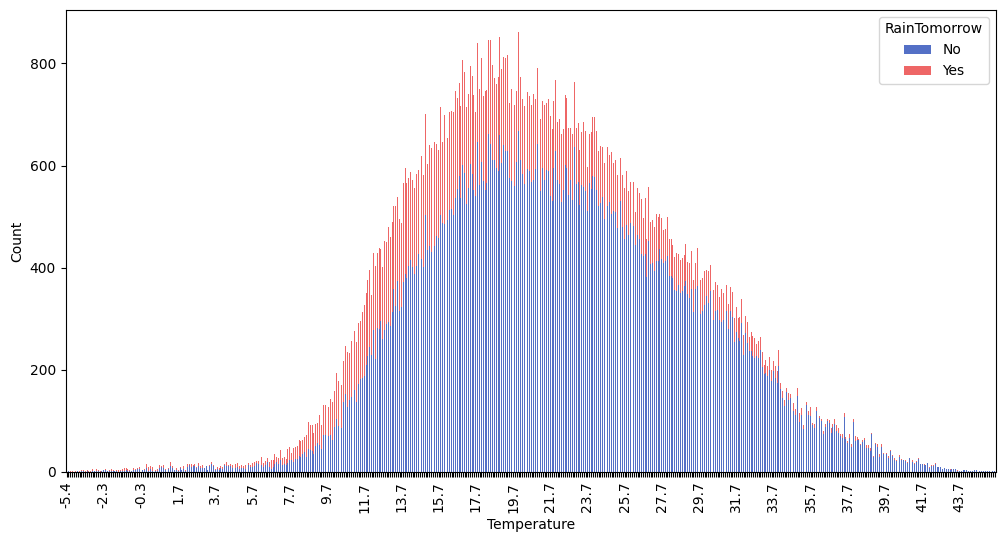

In [ ]:
df_temp_3pm = raw_df.pivot_table(index = "Temp3pm",
                                 columns = "RainTomorrow",
                                 aggfunc = "size")

df_temp_3pm.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'],
                 xlabel = "Temperature", ylabel = "Count", figsize=(12, 6));

ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 20 != 0:
        label.set_visible(False)

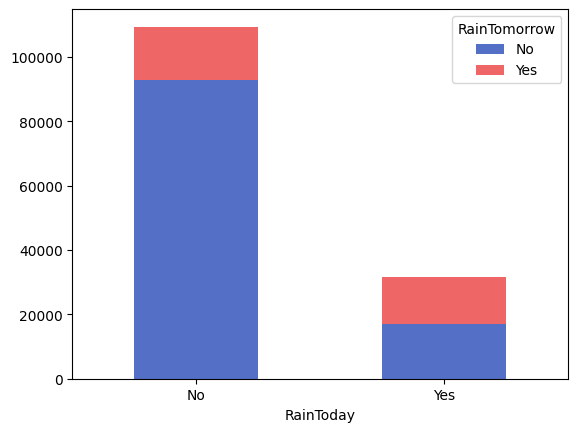

In [ ]:
df_rain_relation = raw_df.pivot_table(index = "RainToday",
                                      columns = "RainTomorrow",
                                      aggfunc = "size")
df_rain_relation.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], rot = 0);

## 2. Train and Test Split

In [ ]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

train_df.shape, val_df.shape, test_df.shape

((97988, 23), (17089, 23), (25710, 23))

## 3. Pre-processing the data

### 3.1 Input Data and Target

In [ ]:
input_cols = list(train_df.columns)[1:-1]
target_col = "RainTomorrow"

In [ ]:
train_inputs = train_df[input_cols].copy()
train_target =  train_df[target_col].copy()

In [ ]:
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

In [ ]:
test_inputs = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

In [ ]:
numeric_cols = train_inputs.select_dtypes(include = np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes("object").columns.tolist()

### 3.2 Impute Values

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = "mean").fit(raw_df[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


### 3.3 Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(raw_df[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

### 3.4 Encoding Categorical Data

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
encoder.fit(raw_df[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_SalmonGums', 'Location_Sydney', 'Location_SydneyAirport', 'Location_Townsville', 'Location_Tuggeranong', 'Location_Uluru', 'Location_WaggaWagga', 'Location_Walpole', 'Location_Watsonia', 'Location_Williamtown', 'Loca

In [ ]:
train_inputs = pd.concat([train_inputs[numeric_cols], pd.DataFrame(encoder.transform(train_inputs[categorical_cols]), columns = encoded_cols, index = train_inputs.index)], axis = 1)
val_inputs = pd.concat([val_inputs[numeric_cols], pd.DataFrame(encoder.transform(val_inputs[categorical_cols]), columns = encoded_cols, index = val_inputs.index)], axis = 1)
test_inputs = pd.concat([test_inputs[numeric_cols], pd.DataFrame(encoder.transform(test_inputs[categorical_cols]), columns = encoded_cols, index = test_inputs.index)], axis = 1)

In [ ]:
train_inputs

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,0.516509,0.523629,0.001617,0.037741,0.526244,0.294574,0.153846,0.275862,0.71,0.22,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.375000,0.565217,0.000000,0.037741,0.526244,0.294574,0.030769,0.252874,0.44,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.504717,0.576560,0.000000,0.037741,0.526244,0.310078,0.146154,0.298851,0.38,0.30,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.417453,0.620038,0.000000,0.037741,0.526244,0.139535,0.084615,0.103448,0.45,0.16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.613208,0.701323,0.002695,0.037741,0.526244,0.271318,0.053846,0.229885,0.82,0.33,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,0.599057,0.718336,0.000000,0.037741,0.526244,0.286822,0.184615,0.298851,0.22,0.13,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144549,0.556604,0.786389,0.000000,0.037741,0.526244,0.193798,0.146154,0.229885,0.16,0.08,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
144550,0.608491,0.805293,0.000000,0.037741,0.526244,0.255814,0.200000,0.103448,0.15,0.08,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144551,0.674528,0.818526,0.000000,0.037741,0.526244,0.286822,0.215385,0.195402,0.22,0.09,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

## 4. Decision Tree Model

### 4.1 Train and Evaluate the Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, train_target)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

train_preds = model.predict(X_train)

accuracy_score(train_preds, train_target)

0.9999795893374699

In [ ]:
model.score(X_val, val_target)

0.7936684416876353

### 4.2 Visualise the Model

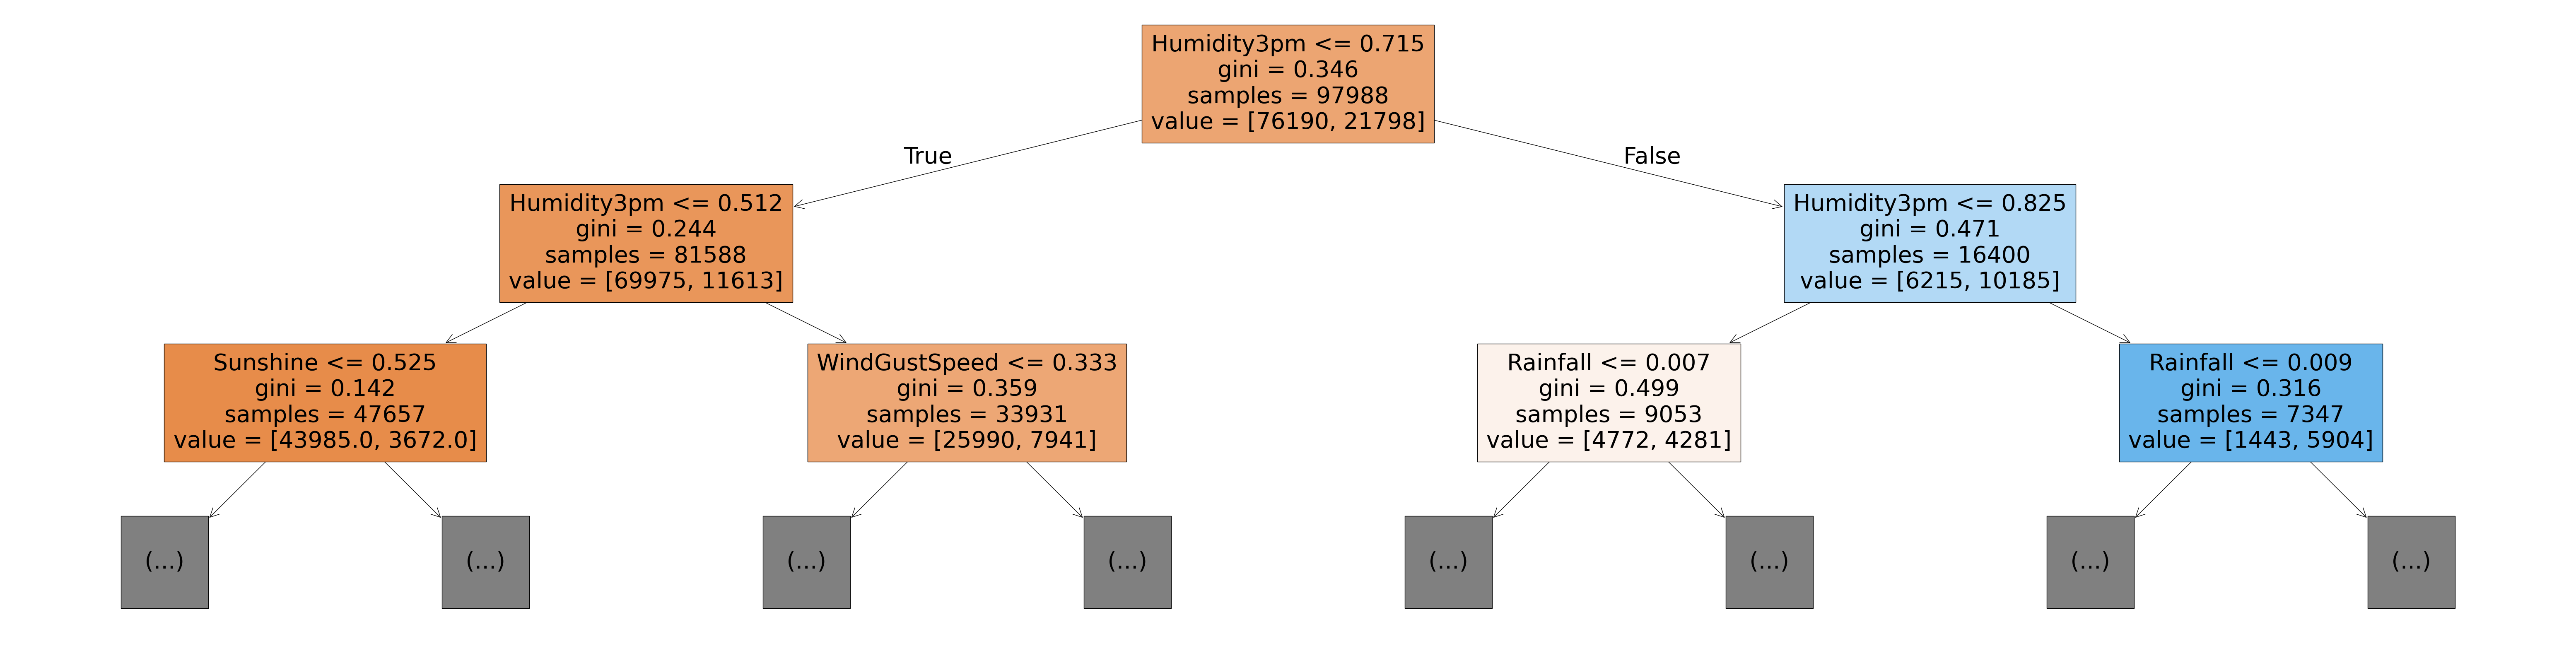

In [ ]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize = (80, 20))
plot_tree(model, feature_names = X_train.columns, max_depth = 2, filled = True);

In [ ]:
model.tree_.max_depth

49

In [ ]:
tree_text = export_text(model, max_depth = 10, feature_names = list(X_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |--- Humidity3pm <= 0.24
|   |   |   |   |   |   |--- WindGustDir_N <= 0.50
|   |   |   |   |   |   |   |--- WindSpeed9am <= 0.32
|   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.06
|   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.06
|   |   |   |   |   |   |   |   |   |   |--- Temp9am <= 0.65
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- Temp9am >  0.65
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- WindSpeed9am >  0.32
|   |   |   |   |   |   |   | 

In [ ]:
model.feature_importances_

array([3.72348864e-02, 3.02750170e-02, 4.46807871e-02, 2.31016443e-02,
       4.74029876e-02, 6.02158346e-02, 2.59596261e-02, 2.87123098e-02,
       3.72718924e-02, 2.78696714e-01, 3.74751640e-02, 6.22463592e-02,
       1.50293521e-02, 1.72695492e-02, 3.51997396e-02, 3.28171151e-02,
       2.07437921e-03, 1.64079963e-03, 1.01783054e-03, 6.88212657e-04,
       1.48034667e-03, 1.10335980e-03, 1.19280342e-03, 1.77001797e-03,
       8.18956871e-04, 1.30986391e-03, 8.00314193e-04, 2.03677225e-03,
       1.38645663e-03, 4.84888047e-04, 6.08349928e-04, 1.26483304e-03,
       1.45258514e-04, 1.50514431e-03, 1.07182434e-03, 1.44829853e-03,
       9.12938347e-04, 8.15936194e-04, 1.26468932e-03, 1.49092396e-03,
       6.60526489e-04, 7.09652768e-04, 1.02344514e-03, 1.54844869e-03,
       1.31824900e-03, 6.07286685e-04, 5.04774518e-04, 1.50976724e-03,
       1.36782184e-03, 2.12844007e-03, 1.24769141e-03, 1.92047622e-03,
       1.46145581e-03, 2.12670031e-03, 1.36401119e-03, 4.10431985e-04,
      

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending = False)

importance_df.head(10)

,feature,importance
9,Humidity3pm,0.278697
11,Pressure3pm,0.062246
5,WindGustSpeed,0.060216
4,Sunshine,0.047403
2,Rainfall,0.044681
10,Pressure9am,0.037475
8,Humidity9am,0.037272
0,MinTemp,0.037235
14,Temp9am,0.035200
15,Temp3pm,0.032817


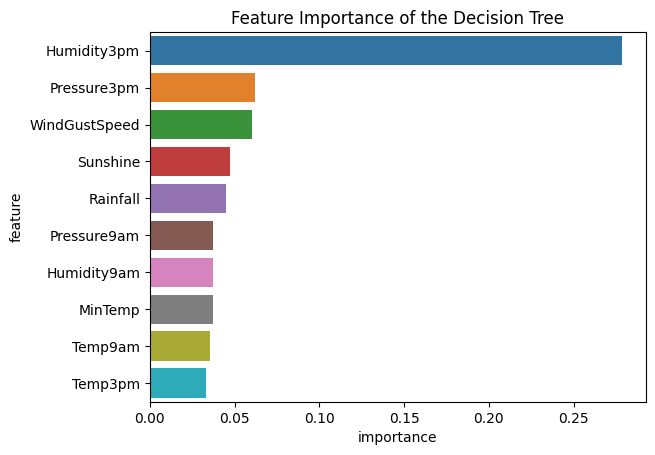

In [ ]:
sns.barplot(data = importance_df.head(10), x = "importance", y = "feature",
            hue = "feature", legend = False, palette = "tab10")
plt.title("Feature Importance of the Decision Tree");

### 4.3 Improve the Model

In [ ]:
model = DecisionTreeClassifier(max_depth = 3, random_state = 42)            # max_depth equals 6 or 7 gives the best result
model.fit(X_train, train_target)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.score(X_train, train_target)

0.8315916234640977

In [ ]:
model.score(X_val, val_target)

0.8348060155655685

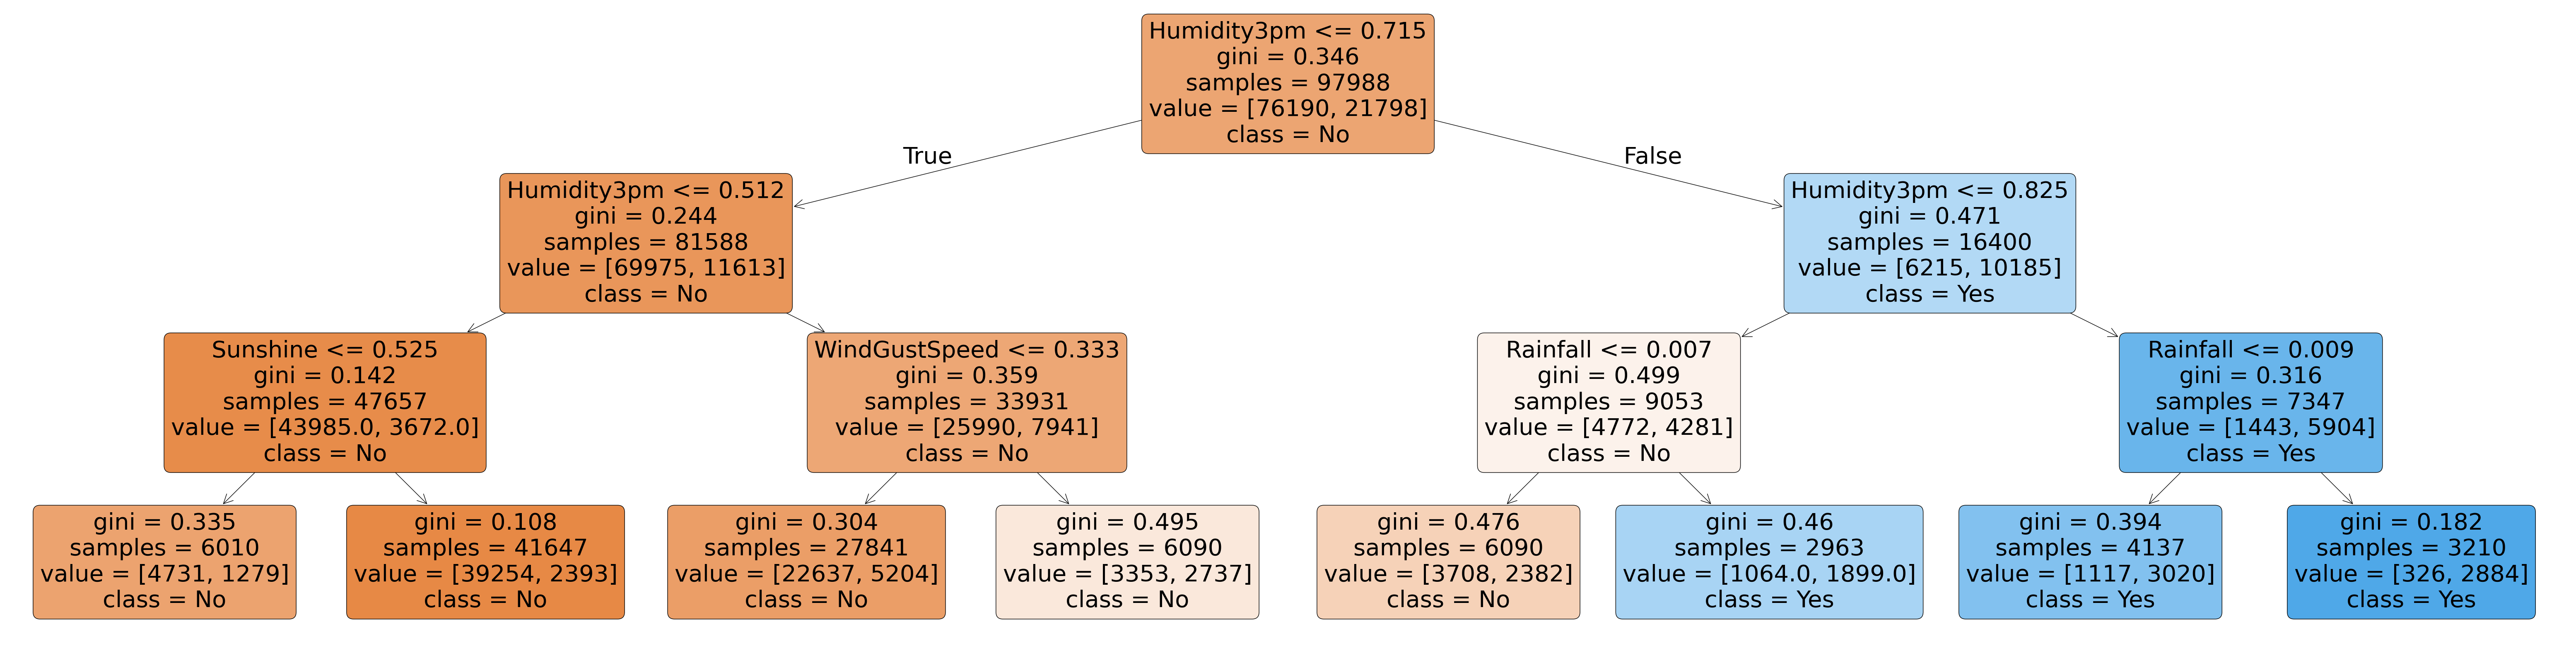

In [ ]:
plt.figure(figsize = (80, 20))
plot_tree(model, feature_names = X_train.columns, filled = True, rounded = True, class_names = model.classes_);

In [ ]:
print(export_text(model, feature_names = list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.53
|   |   |   |--- class: No
|   |--- Humidity3pm >  0.51
|   |   |--- WindGustSpeed <= 0.33
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.33
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: No
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



### 4.4 `max_leaf_nodes`

In [ ]:
model = DecisionTreeClassifier(max_leaf_nodes = 128, random_state = 42)
model.fit(X_train, train_target)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [ ]:
model.score(X_train, train_target)

0.852696248520227

In [ ]:
model.score(X_val, val_target)

0.8471531394464276

In [ ]:
model.tree_.max_depth

11

In [ ]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': 128,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### 4.5 Search for the Best Model

Validation Accuracy to beat: 0.8471531394464276

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

class_weights = [
    {"No": 1, "Yes": 1.5},
    {"No": 1, "Yes": 1.65},
    {"No": 1, "Yes": 1.8},
    {"No": 1, "Yes": 1.8}]

parameters_grid = {
    #"max_depth": [5, 7, 10, 13, 16, 19, 22, 25, 28, 30],
    #"min_samples_split": (np.arange(2, 11, 1)).tolist(),
    "min_samples_split": [2],
    #"min_samples_leaf": [1, 2, 4, 6, 8, 10],
    "min_samples_leaf": [1],
    "max_leaf_nodes": [32, 64, 128, 256, 512, 1024],
    #"max_fetures": 1000,
    "class_weight": class_weights
}


In [ ]:
model_basic = DecisionTreeClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = model_basic,
                           param_grid = parameters_grid,
                           cv = 5,
                           n_jobs = -1,
                           verbose = 2,
                           scoring = "accuracy")

grid_search.fit(X_train, train_target)
model_best_grid_search = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
train_preds_best_grid = model_best_grid_search.predict(X_train)
accuracy_score(train_preds_best_grid, train_target)

0.8405008776584888

In [ ]:
model_best_grid_search.score(X_val, val_target)

0.8413014219673474

In [ ]:
model_best_grid_search.score(X_test, test_target)

0.827460132244263

In [ ]:
best_param_d_tr = grid_search.best_params_  # The parameters of the most accurate decision tree model
print(f"The best parameters of the decision tree model: {best_param_d_tr}")

The best parameters of the decision tree model: {'class_weight': {'No': 1, 'Yes': 1.65}, 'max_leaf_nodes': 32, 'min_samples_leaf': 1, 'min_samples_split': 2}


### 4.6 The Best Model that is Fine-Tuned

In [ ]:
model_best = DecisionTreeClassifier(max_depth = 10,
                                    min_samples_split = 2,
                                    min_samples_leaf = 1,
                                    random_state = 42,
                                    max_leaf_nodes = 256)  #256, 278
                                    #class_weight = {"No": 1.0, "Yes": 1.3})

In [ ]:
model_best.fit(X_train, train_target)
preds_train_best_model = model_best.predict(X_train)

accuracy_score(preds_train_best_model, train_target)

0.8553394293178757

In [ ]:
model_best.score(X_val, val_target)

0.8422962139387911

In [ ]:
model_best.score(X_test, test_target)

0.8287825748735901

## 5. Train a Random Forest Model

### 5.1 Implement a Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_jobs = -1, random_state = 42)
model.fit(X_train, train_target)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
model.score(X_train, train_target)

0.9999693840062048

In [ ]:
model.score(X_val, val_target)

0.8567499561121189

In [ ]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.96, 0.04],
       [0.98, 0.02],
       [0.98, 0.02],
       ...,
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.94, 0.06]])

In [ ]:
len(model.estimators_)

100

In [ ]:
model.estimators_[0]
# view the whole data

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

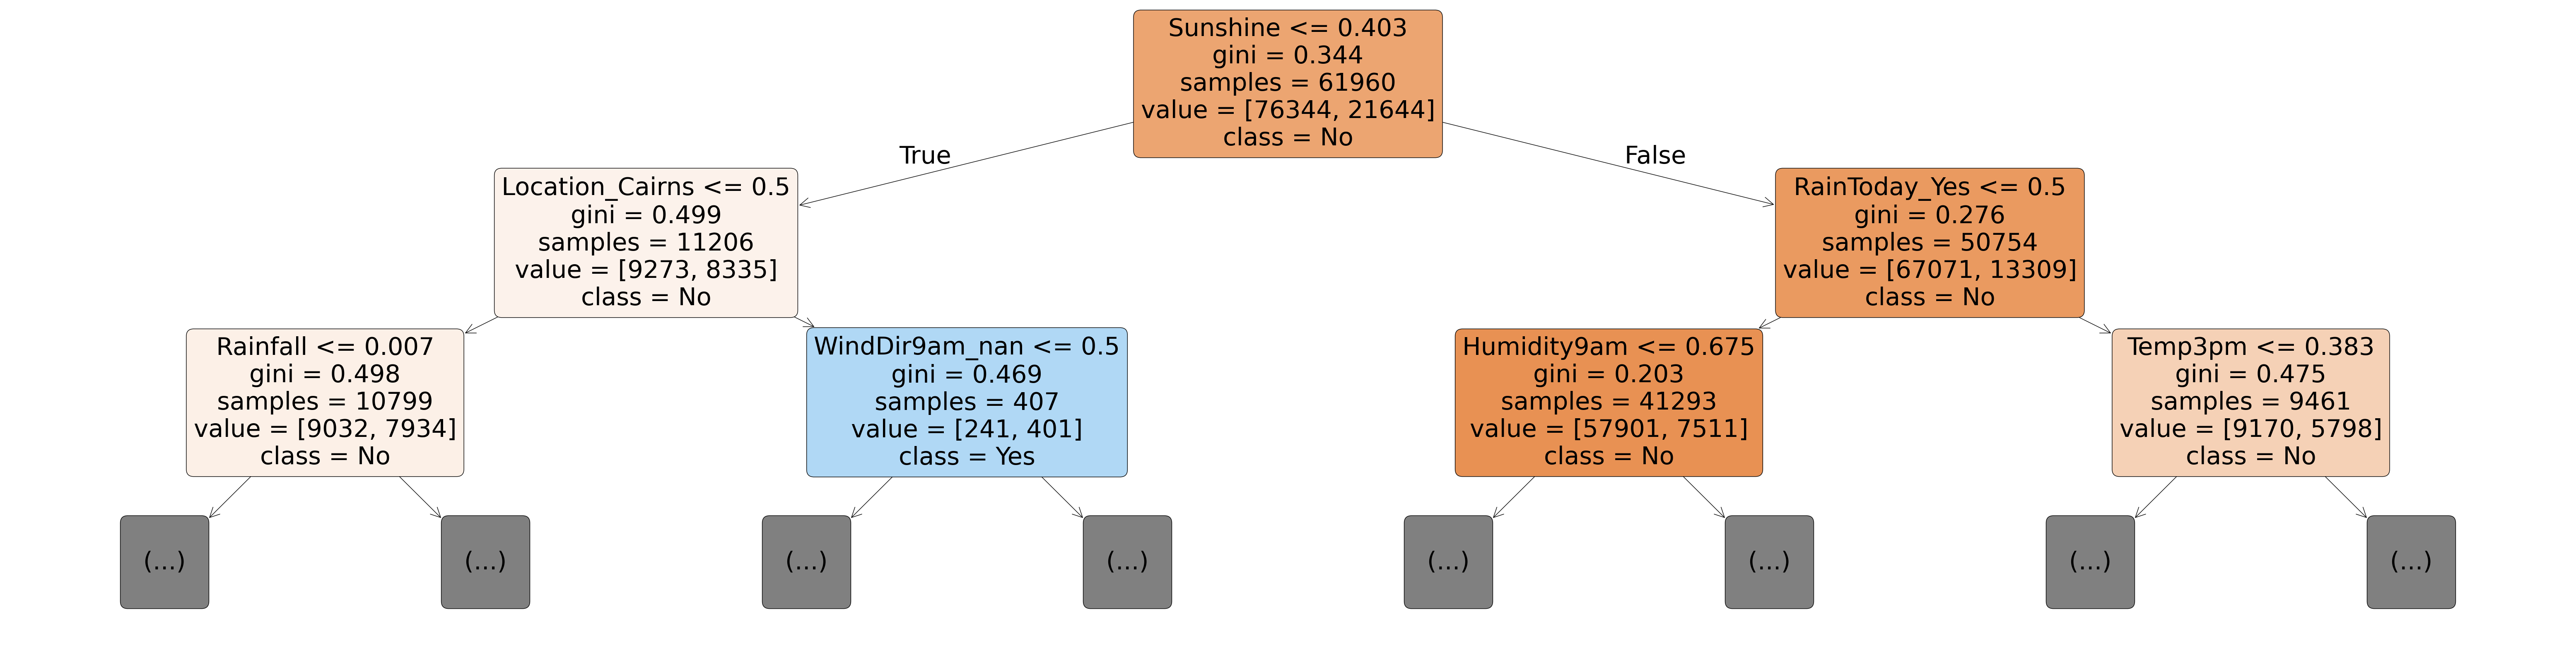

In [ ]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[0], max_depth = 2, feature_names = X_train.columns, filled = True, rounded = True, class_names = model.classes_);

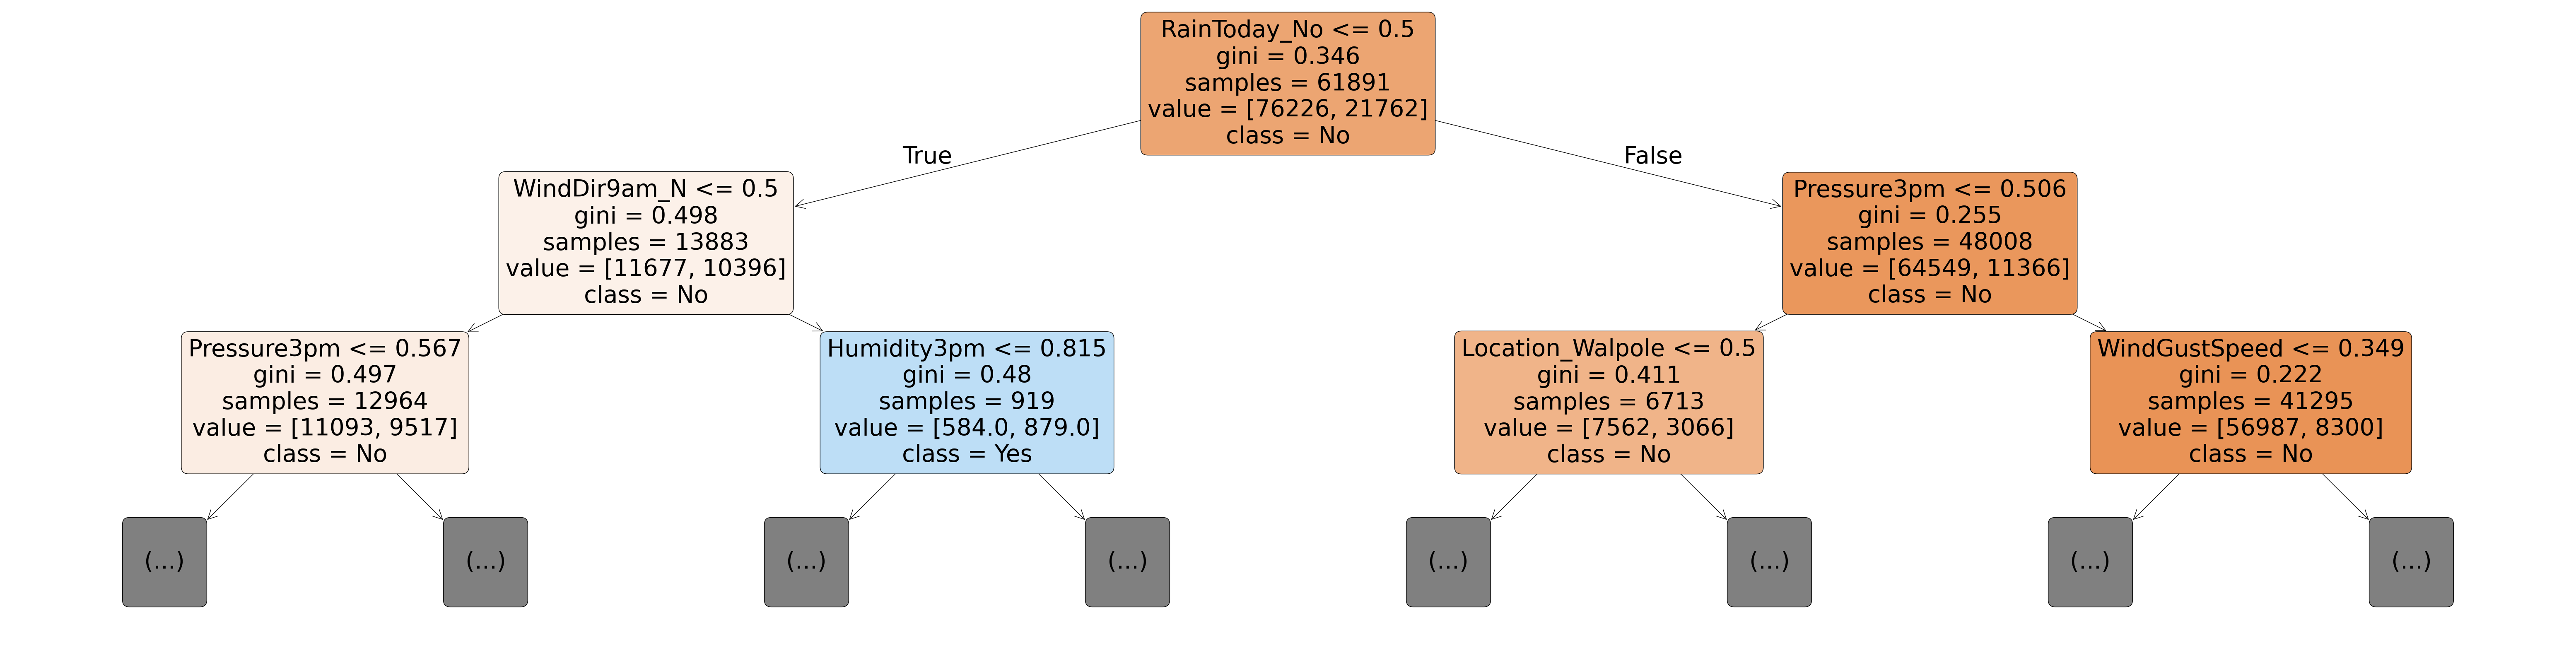

In [ ]:
plt.figure(figsize = (80, 20))
plot_tree(model.estimators_[31], max_depth = 2, feature_names = X_train.columns, filled = True, rounded = True, class_names = model.classes_);

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending = False)

importance_df.head(10)

,feature,importance
9,Humidity3pm,0.129273
4,Sunshine,0.059835
11,Pressure3pm,0.053178
8,Humidity9am,0.051036
10,Pressure9am,0.049215
5,WindGustSpeed,0.047183
2,Rainfall,0.046710
15,Temp3pm,0.046196
1,MaxTemp,0.042871
0,MinTemp,0.042163


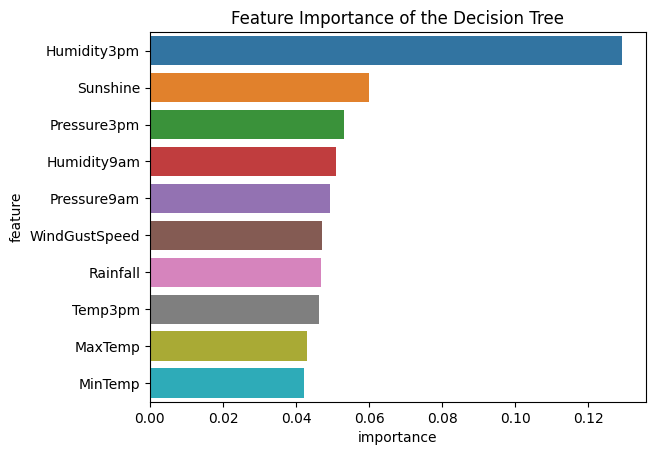

In [ ]:
sns.barplot(data = importance_df.head(10), x = "importance", y = "feature",
            hue = "feature", legend = False, palette = "tab10")
plt.title("Feature Importance of the Decision Tree");

### 5.2 Fine-tune the Model

In [ ]:
base_model = RandomForestClassifier(n_jobs = -1, random_state = 42).fit(X_train, train_target)

In [ ]:
base_train_acc = base_model.score(X_train, train_target)
base_val_acc = base_model.score(X_val, val_target)

In [ ]:
base_train_acc, base_val_acc

(0.9999693840062048, 0.8567499561121189)

In [ ]:
model = RandomForestClassifier(n_jobs = -1, random_state = 42, n_estimators = 10)       # you could increase n_estimators 50-500
model.fit(X_train, train_target)

RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=42)

In [ ]:
model.score(X_train, train_target), model.score(X_val, val_target)      # Max_depth 27 gave the best result...

(0.9869882026370576, 0.8447539352800046)